## Multiclass Classification

In [ ]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

'''
왜 transform 이용??

많은 데이터셋들이 tensor 그리고 개 채 행 렬 꼴로 되어있다는 보장 x
'''

In [2]:
DEVICE = "mps" if torch.mps.is_available() else "cpu"
print(DEVICE)

mps


### Train_DS와 test_DS 구경하자..

In [ ]:
transform = transforms.ToTensor()
train_DS = datasets.MNIST(root = '/Volumes/김상현/dataset', train = True, download = False, transform = transform)
test_DS = datasets.MNIST(root = '/Volumes/김상현/dataset', train = False, download = False, transform = transform)

100.0%
100.0%
100.0%
100.0%


In [7]:
print(train_DS)
print(test_DS)
print(len(train_DS))
print(len(test_DS))

Dataset MNIST
    Number of datapoints: 60000
    Root location: /Volumes/김상현/dataset
    Split: Train
    StandardTransform
Transform: ToTensor()
Dataset MNIST
    Number of datapoints: 10000
    Root location: /Volumes/김상현/dataset
    Split: Test
    StandardTransform
Transform: ToTensor()
60000
10000


In [8]:
train_DS.classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [9]:
train_DS.class_to_idx

{'0 - zero': 0,
 '1 - one': 1,
 '2 - two': 2,
 '3 - three': 3,
 '4 - four': 4,
 '5 - five': 5,
 '6 - six': 6,
 '7 - seven': 7,
 '8 - eight': 8,
 '9 - nine': 9}

In [10]:
train_DS.data.shape

torch.Size([60000, 28, 28])

In [11]:
train_DS.data[0]

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

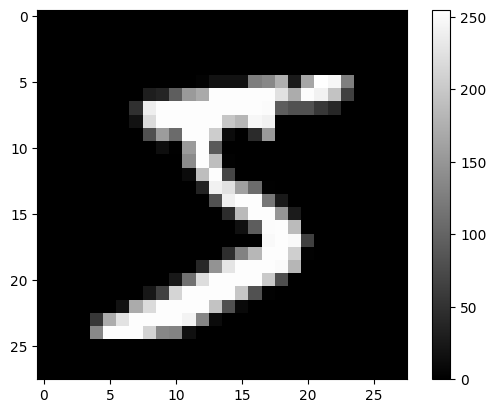

In [13]:
plt.imshow(train_DS.data[0], cmap="gray")
plt.colorbar()
plt.show()

In [14]:
print(train_DS.targets)
print(train_DS.targets.shape)

tensor([5, 0, 4,  ..., 5, 6, 8])
torch.Size([60000])


### DataLoader

In [105]:
BATCH_SIZE = 32
train_DL = torch.utils.data.DataLoader(train_DS, batch_size=BATCH_SIZE, shuffle=True)
test_DL = torch.utils.data.DataLoader(test_DS, batch_size=BATCH_SIZE, shuffle=True)

In [106]:
print(len(train_DL.dataset))

60000


In [108]:
# next(iter(train_DL)) -> 데이터 한 국자 scoop -> 근데 batchsize가 32라서 32개 뽑!
x_batch, y_batch = next(iter(train_DL))
print(type(train_DS.data))
print(type(x_batch.shape))
print(x_batch.shape)
print(y_batch.shape) # label
print(y_batch[0])

<class 'torch.Tensor'>
<class 'torch.Size'>
torch.Size([32, 1, 28, 28])
torch.Size([32])
tensor(5)


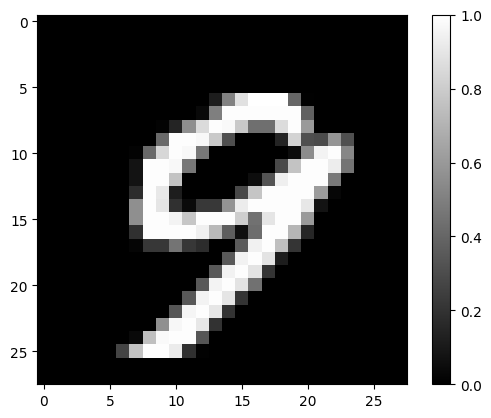

tensor(9)


In [37]:
#plt.imshow(x_batch[0]) # 채널 1이라서 -> unsqeeze
plt.imshow(x_batch[0].squeeze(), cmap = 'gray')
plt.colorbar()
plt.show()
print(y_batch[0])
# ToTensor 의 역할
# 1. tensor로 바꿔준다
# 2. 개채행열로 바꿔준다
# 3. 0~1 사이로 바꿔준다 (int -> float)

In [109]:
from torch import nn

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.linear = nn.Sequential(nn.Linear(28 * 28, 100),
                                    nn.ReLU(),
                                    nn.Linear(100, 10))
        
    def forward(self, x):
        x = torch.flatten(x, start_dim=1) # 개 채 행 렬 -> 개 , 행*열
        x = self.linear(x)
        return x

In [42]:
print(x_batch.shape)
print(torch.flatten(x_batch).shape)
print(torch.flatten(x_batch, start_dim=1).shape)

torch.Size([32, 1, 28, 28])
torch.Size([25088])
torch.Size([32, 784])


In [110]:
model = MLP()
print(model)
x_batch, _ = next(iter(train_DL))
print(model(x_batch).shape)

MLP(
  (linear): Sequential(
    (0): Linear(in_features=784, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=10, bias=True)
  )
)
torch.Size([32, 10])


In [ ]:
from torch import optim
LR = 1e-3
EPOCH = 20
criterion = nn.CrossEntropyLoss()

def Train(model, train_DL, criterion, optimizer):
    
    loss_history = []
    NoT = len(train_DL.dataset)
    
    model.train()
    for ep in range(EPOCH):
        rloss = 0 # running loss
        for x_batch, y_batch in train_DL: # 지금은 SGD로 즉 minibatch 실행하니깐!! train_DL에서 loop를 돌려서 배치마다 훈련
            x_batch = x_batch.to(DEVICE) # 데이터들을 gpu에 올리는 역할!
            y_batch = y_batch.to(DEVICE)
            
            # inference
            y_hat = model(x_batch)
            
            # loss
            loss = criterion(y_hat, y_batch) # <1/batch_size sum(CE_n)>
            
            # update
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # loss accumulation
            loss_b = loss.item() * x_batch.shape[0] # batch loss # BATCH_SIZE를 곱하면 마지막 18개도 32개를 곱하니까..
                                                    # 즉 데이터가 모두 균등한 사이즈로 안나눠질 수 있기때문에
            rloss+= loss_b
    
        # print loss    
        loss_e = rloss/NoT
        loss_history += [loss_e] # to print all train_set 즉 <1/6만 sum(CE_n)>
        print(f"Epoch: {ep+1}, train loss: {round(loss_e,3)}")
        print("-"*20)
    return loss_history 

In [87]:
y_hat.sum(dim=1, keepdim=True)

tensor([[ 3.2952],
        [-0.4214],
        [-0.4701]])

### Cross Entropy 확인 (왜 모델에 softmax를 안붙였을까?)

In [ ]:
# cross entropy 구하는 여러가지 방법
import torch.nn.functional as F

y_hat = torch.randn(3, 5) # data는 세 개 , 5종류로 분류하는 문제 가정 + 이미 MLP 다 통과된 마지막 output layer values
print(y_hat)
print("가로 축으로 즉 하나의 데이터 행에서 각 value의 합이 1이 아님->아직 확률이 안된다.","\n",y_hat.sum(dim=1))

y_batch = torch.randint(5, (3,)) # torch.randint(상한값, (size)), (3, ) ?? -> 1차원 tensor는 ","로 처리
print(y_batch)

# 방법 1
loss = F.cross_entropy(y_hat, y_batch) # softmax가 내장
print("use functional:",loss)


def my_softmax(predict):
    
    exp_predict = torch.exp(predict)
    
    # exp_predict 전체 합을 각 원소에 나눠주기
    sum_exp = exp_predict.sum(dim=1, keepdim=True)
    
    return exp_predict/sum_exp

def my_CE(predict, y_batch):
    
    prob = my_softmax(predict)
    
    eps = 1e-7
    log_prob = torch.log(prob + eps)
    
    N = predict.shape[0]
    
    N, K = predict.shape
    one_hot = torch.zeros(N,K)
    one_hot[range(N), y_batch] = 1 # 정답 위치면 1
    
    loss = -(one_hot * log_prob).sum() / N
    
    return loss

print("scratch loss: ",my_CE(y_hat, y_batch))



# 방법 2
criterion = nn.CrossEntropyLoss() # softmax가 내장
print("CrossEntropyLoss() 이용: ",criterion(y_hat, y_batch))

# 방법 3 ######### --> 복습!!!!!!!!!!
y_hat_soft = F.softmax(y_hat, dim=1)
loss = 0
for i, val in enumerate(y_hat_soft): # 이 방법 지리네
    print(i, val)
    loss += -torch.log(val[y_batch[i]])
print(loss/3) # 평균이 내장되어있음을 알 수 있다



tensor([[-0.9112, -0.5258, -0.3496, -1.6997, -0.9941],
        [ 0.9797,  0.4644,  0.6634,  1.4624, -0.4572],
        [-0.0540,  1.1717, -0.5278, -0.0926, -0.4532]])
가로 축으로 즉 하나의 데이터 행에서 각 value의 합이 1이 아님->아직 확률이 안된다. 
 tensor([-4.4804,  3.1127,  0.0440])
tensor([3, 0, 0])
use functional: tensor(1.9463)
scratch loss:  tensor(1.9463)
CrossEntropyLoss() 이용:  tensor(1.9463)
0 tensor([0.1786, 0.2626, 0.3132, 0.0812, 0.1644])
1 tensor([0.2390, 0.1428, 0.1742, 0.3873, 0.0568])
2 tensor([0.1501, 0.5113, 0.0935, 0.1444, 0.1007])
tensor(1.9463)


tensor([3, 0, 0])

In [104]:
y_hat_soft = F.softmax(y_hat, dim=1)
loss = 0
for i, val in enumerate(y_hat_soft):
    print(i, val)
    print(val[y_batch[i]])
    print(val[2])
    


0 tensor([0.1786, 0.2626, 0.3132, 0.0812, 0.1644])
tensor(0.0812)
tensor(0.3132)
1 tensor([0.2390, 0.1428, 0.1742, 0.3873, 0.0568])
tensor(0.2390)
tensor(0.1742)
2 tensor([0.1501, 0.5113, 0.0935, 0.1444, 0.1007])
tensor(0.1501)
tensor(0.0935)


In [102]:
y_batch

tensor([4, 3, 3])

### 모델 학습시키기

Epoch: 1, train loss: 0.304
--------------------
Epoch: 2, train loss: 0.139
--------------------
Epoch: 3, train loss: 0.096
--------------------
Epoch: 4, train loss: 0.074
--------------------
Epoch: 5, train loss: 0.058
--------------------
Epoch: 6, train loss: 0.047
--------------------
Epoch: 7, train loss: 0.039
--------------------
Epoch: 8, train loss: 0.032
--------------------
Epoch: 9, train loss: 0.026
--------------------
Epoch: 10, train loss: 0.022
--------------------
Epoch: 11, train loss: 0.019
--------------------
Epoch: 12, train loss: 0.017
--------------------
Epoch: 13, train loss: 0.012
--------------------
Epoch: 14, train loss: 0.013
--------------------
Epoch: 15, train loss: 0.01
--------------------
Epoch: 16, train loss: 0.009
--------------------
Epoch: 17, train loss: 0.008
--------------------
Epoch: 18, train loss: 0.009
--------------------
Epoch: 19, train loss: 0.006
--------------------
Epoch: 20, train loss: 0.007
--------------------


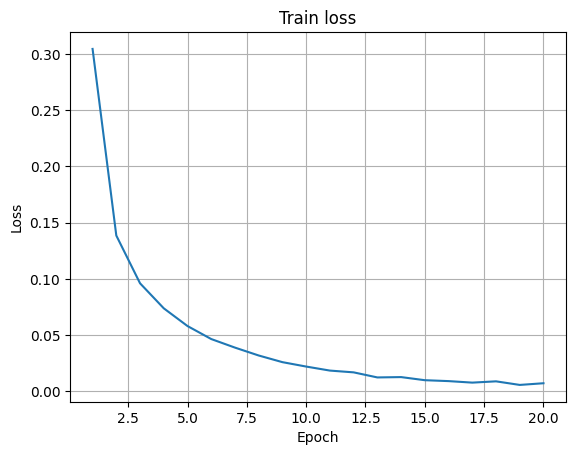

In [112]:
model = MLP().to(DEVICE) # x_batch, y_batch, model까지 DEVICE에 올려줘야함
optimizer = optim.Adam(model.parameters(), lr = LR)
loss_history = Train(model, train_DL, criterion, optimizer)

plt.plot(range(1, EPOCH + 1), loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title("Train loss")
plt.grid()

### 모델 저장하기 & 불러오기

In [113]:
save_model_path = '/Volumes/김상현/results/Multiclass_Classification_MNIST/MLP_MNIST.pt'
torch.save(model.state_dict(), save_model_path)

In [114]:
model.state_dict()

OrderedDict([('linear.0.weight',
              tensor([[-0.0113, -0.0204,  0.0168,  ...,  0.0324, -0.0225,  0.0211],
                      [-0.0251,  0.0150, -0.0025,  ...,  0.0028,  0.0226,  0.0050],
                      [ 0.0103,  0.0199,  0.0336,  ..., -0.0272,  0.0061, -0.0084],
                      ...,
                      [-0.0068, -0.0254,  0.0033,  ...,  0.0209,  0.0112,  0.0258],
                      [ 0.0353, -0.0312,  0.0057,  ..., -0.0334, -0.0304,  0.0317],
                      [ 0.0047,  0.0065, -0.0085,  ...,  0.0349, -0.0340, -0.0347]],
                     device='mps:0')),
             ('linear.0.bias',
              tensor([ 0.0306,  0.2324,  0.2936,  0.1078, -0.1795,  0.1959,  0.1181, -0.1901,
                      -0.2000,  0.3707, -0.0140,  0.0328,  0.2833, -0.1028, -0.0247, -0.3010,
                       0.1767,  0.2322,  0.1331,  0.1456, -0.1275,  0.1819, -0.0108, -0.0654,
                       0.2689, -0.0735,  0.4357,  0.4452,  0.0135,  0.3844, -0.0368

In [ ]:
load_model = MLP().to(DEVICE) # 일단 불러올 모델과 같은 모델(껍데기)를 만든다.
load_model.load_state_dict(torch.load(save_model_path, map_location = DEVICE)) # map_location => GPU로 학습한건 GPU로 불러와야함.

<All keys matched successfully>

In [133]:
### 모델 테스트!
def Test(model, test_DL):
    model.eval()
    with torch.no_grad():
        rcorrect = 0
        for x_batch, y_batch in test_DL: # test도 배치를 나누어서 하나?
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            
            y_hat = model(x_batch)
            
            pred = y_hat.argmax(dim=1) # 가장 큰 확률이 그 레이블으로 모델이 판단 내렸기 때문에 argmax로 가장 큰 값을 찾아야한다.
            correct_b = torch.sum(pred == y_batch).item()
            rcorrect += correct_b
        accuracy_e = rcorrect/len(test_DL.dataset)*100
    print(f"Test accuracy: {rcorrect}/{len(test_DL.dataset)} ({round(accuracy_e, 1)} %)")

In [131]:
y_hat.shape

torch.Size([32, 10])

In [132]:
tmp_x_batch, tmp_y_batch = next(iter(test_DL))
# print("="*15, "뽑은 값", "="*15)
# print("뽑은 x batch values:",tmp_x_batch)
# print("뽑은 y_batch_values",tmp_y_batch)
# print("="*15, "뽑은 값", "="*15)


model.eval()

with torch.no_grad():
    tmp_x_batch = tmp_x_batch.to(DEVICE)
    tmp_y_batch = tmp_y_batch.to(DEVICE)
    y_hat = model(tmp_x_batch)
    
print("="*15, "output layer 통과 후 값들-> logit, softmax ㄴㄴㄴ", "="*15)
print(y_hat)
print(y_hat.argmax(dim=1))
print("="*15, "실제 레이블들", "="*15)
print(tmp_y_batch)
print(test_DS.class_to_idx)

print("="*15, "한 batch에서 정답 갯수", "="*15)
print(y_hat.argmax(dim=1) == tmp_y_batch)
print(torch.sum(y_hat.argmax(dim=1)== tmp_y_batch))

=============== output layer 통과 후 값들-> logit, softmax ㄴㄴㄴ ===============
tensor([[-1.4179e+01, -1.6189e+01, -2.3917e+01, -1.7709e+01,  9.6978e-01,
          4.6807e-01, -2.5010e+01, -2.4242e+00, -1.4586e+01, -7.8698e+00],
        [ 3.1085e+00, -4.3678e+01, -5.5661e+00, -1.3344e+01, -1.2013e+01,
         -1.7960e+00,  1.9896e+01, -3.0937e+01,  5.9736e+00, -1.5507e+01],
        [-2.1834e+01, -1.9126e+00, -4.1943e+00, -1.1015e+01, -1.7235e+01,
         -1.0561e+01,  2.0396e+01, -2.7538e+01, -1.9739e+00, -4.4257e+01],
        [ 2.9098e+01, -4.1244e+01,  5.6513e+00, -2.3880e+01, -3.3863e+01,
         -2.0595e+01, -3.4675e+00, -3.8324e+01, -6.1088e+00, -2.4017e+01],
        [-1.0005e+01, -2.2205e+01, -1.0825e+01, -8.6912e+00,  1.0708e+01,
         -9.8394e+00, -9.3686e+00, -4.5528e+00, -3.2229e+00, -1.2151e+01],
        [-1.5864e+01, -2.8216e+01, -8.2907e+00, -5.5859e+00, -4.1031e+01,
         -2.1639e+01, -4.6258e+01,  1.7345e+01, -1.6778e+01, -4.7044e+00],
        [-2.2898e+01,  1.3323e+0

Case 2처럼 되는 일은 절대 없어. 걱정 안 해도 돼.
이유를 차근차근 설명해줄게.
핵심: 모델의 출력 인덱스 = 클래스 번호
네가 만든 모델의 마지막 레이어가 nn.Linear(100, 10)이잖아. 이게 뭘 의미하냐면, 출력 뉴런이 10개라는 거고, 각 뉴런의 인덱스가 곧 클래스 번호야.
즉, 출력 벡터 y_hat이 10차원이면:

y_hat[0] → 숫자 0일 확률(정확히는 logit)
y_hat[1] → 숫자 1일 확률
y_hat[2] → 숫자 2일 확률
...
y_hat[9] → 숫자 9일 확률

이건 모델 구조 자체가 그렇게 설계된 거야. 사진의 Case 1처럼 인덱스 0은 항상 "숫자 0", 인덱스 4는 항상 "숫자 4"야.
그러면 이게 어떻게 보장되느냐?
학습(training) 과정에서 자동으로 보장돼. 예를 들어 학습할 때 CrossEntropyLoss를 쓰잖아?
pythonloss = nn.CrossEntropyLoss()(y_hat, y_label)
여기서 y_label = 4라고 하면, 이 loss 함수가 하는 일은:

"y_hat의 4번 인덱스 값이 제일 크도록 만들어라"

라고 gradient를 보내는 거야. 즉, ground truth label 값 4가 출력 벡터의 4번째 인덱스와 직접적으로 매핑되어 학습이 진행돼.
그러니까 학습이 끝난 후에 argmax를 했을 때 4가 나오면, 그건 진짜로 "이 이미지가 숫자 4다"라는 뜻이 맞는 거야.
네 사진에서 Case 2가 불가능한 이유
Case 2는 ground truth label이 3, 4, 5, 8, 9, 7, 1, 2, 6 이런 식으로 뒤죽박죽 매핑되는 건데, 이건 출력 인덱스와 클래스 번호 사이에 별도의 매핑 테이블이 있다는 뜻이잖아. MNIST 같은 경우엔 그런 거 없어. 레이블 자체가 0~9 정수이고, 출력 레이어의 인덱스가 곧 그 정수야.
한 줄 요약

argmax(y_hat) = 가장 높은 logit의 인덱스 = 예측 클래스 번호이고, 이건 ground truth label의 번호 체계와 동일하다. 이걸 CrossEntropyLoss가 학습 과정에서 자동으로 맞춰준다.

그래서 테스트할 때 y_hat.argmax(dim=1)과 tmp_y_batch를 바로 비교해도 아무 문제 없어!

In [154]:
Test(load_model, test_DL)

Test accuracy: 9762/10000 (97.6 %)


In [139]:
def Test_plot(model, test_DL):
    model.eval()
    with torch.no_grad():
        x_batch, y_batch = next(iter(test_DL))
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        y_hat = model(x_batch)
        pred = y_hat.argmax(dim=1)
        
    x_batch = x_batch.to("cpu")
     
    plt.figure(figsize=(8,4))
    for idx in range(6):
        plt.subplot(2, 3, idx+1, xticks=[], yticks=[])
        plt.imshow(x_batch[idx].permute(1,2,0).squeeze(), cmap="gray")
        pred_class = test_DL.dataset.classes[pred[idx]]
        true_class = test_DL.dataset.classes[y_batch[idx]]
        plt.title(f"{pred_class} ({true_class})", color = "g" if pred_class==true_class else "r") 

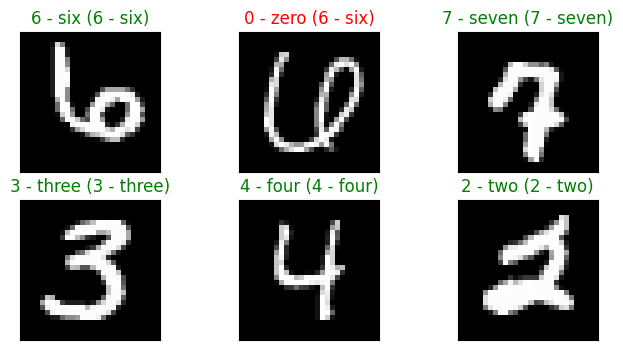

In [162]:
Test_plot(load_model, test_DL)

In [152]:
num = sum([p.numel() for p in model.parameters() if p.requires_grad])
print(num)

79510


In [155]:
def count_params(model):
    num = sum([p.numel() for p in model.parameters() if p.requires_grad])
    return num

In [156]:
print(count_params(load_model))

79510
